# Lab 7 — Model Evaluation Metrics

**Name:** Amir Ali Eslami  
**Student Number:** 501200510  
**Course:** CCPS 844 — Data Mining

This notebook covers:
1. Quiz Part I — MAE, MSE, RMSE (HPI)
2. Quiz Part II — Confusion-matrix metrics (M/W)
3. Quiz Part III — Threshold adjustment for sensitivity
4. Practical — Advertising regression metrics
5. Practical — Pima Indians Diabetes classification metrics, ROC/AUC, k-fold CV


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import binarize

np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
print('Libraries loaded.')


Libraries loaded.


## I — Calculate MAE, MSE, RMSE (HPI)

Formulas:

- $MAE = \frac{1}{n}\sum |y_i - \hat{y}_i|$
- $MSE = \frac{1}{n}\sum (y_i - \hat{y}_i)^2$
- $RMSE = \sqrt{MSE}$


In [2]:
actual = np.array([175, 216, 288, 298, 193, 159, 183, 278, 189, 223, 297], dtype=float)
predicted = np.array([135, 256, 231, 267, 139, 150, 127, 216, 139, 250, 264], dtype=float)

errors = actual - predicted
abs_errors = np.abs(errors)
sq_errors = errors ** 2

df_hpi = pd.DataFrame({
    'HPI Actual': actual.astype(int),
    'HPI Predicted': predicted.astype(int),
    'Absolute Error': abs_errors,
    'Squared Error': sq_errors,
})
display(df_hpi)

n = len(actual)
MAE = abs_errors.mean()
MSE = sq_errors.mean()
RMSE = np.sqrt(MSE)

print(f'n = {n}')
print(f'Sum of absolute errors = {abs_errors.sum():.0f}')
print(f'Sum of squared errors  = {sq_errors.sum():.0f}')
print()
print(f'MAE  = {MAE:.4f}')
print(f'MSE  = {MSE:.4f}')
print(f'RMSE = {RMSE:.4f}')


,HPI Actual,HPI Predicted,Absolute Error,Squared Error
0,175,135,40.000000,1600.000000
1,216,256,40.000000,1600.000000
2,288,231,57.000000,3249.000000
3,298,267,31.000000,961.000000
4,193,139,54.000000,2916.000000
5,159,150,9.000000,81.000000
6,183,127,56.000000,3136.000000
7,278,216,62.000000,3844.000000
8,189,139,50.000000,2500.000000
9,223,250,27.000000,729.000000


n = 11
Sum of absolute errors = 459
Sum of squared errors  = 21705

MAE  = 41.7273
MSE  = 1973.1818
RMSE = 44.4205


### Part I Answers

| Metric | Value |
|--------|------:|
| MAE | **41.7273** |
| MSE | **1973.1818** |
| RMSE | **44.4205** |


## II — TP, FP, TN, FN and Classification Metrics

Positive class = **M**, Negative class = **W**.


In [3]:
pairs = [
    ('M', 'W'),
    ('M', 'M'),
    ('W', 'W'),
    ('M', 'M'),
    ('W', 'M'),
    ('W', 'W'),
    ('W', 'W'),
    ('M', 'M'),
    ('M', 'W'),
    ('W', 'W'),
]

rows = []
for i, (actual, pred) in enumerate(pairs, start=1):
    if actual == 'M' and pred == 'M':
        outcome = 'TP'
    elif actual == 'W' and pred == 'M':
        outcome = 'FP'
    elif actual == 'W' and pred == 'W':
        outcome = 'TN'
    else:
        outcome = 'FN'
    rows.append({'#': i, 'Actual': actual, 'Predicted': pred, 'Outcome': outcome})

df_mw = pd.DataFrame(rows)
display(df_mw)

TP = (df_mw['Outcome'] == 'TP').sum()
FP = (df_mw['Outcome'] == 'FP').sum()
TN = (df_mw['Outcome'] == 'TN').sum()
FN = (df_mw['Outcome'] == 'FN').sum()
total = TP + FP + TN + FN

accuracy = (TP + TN) / total
class_error = (FP + FN) / total
precision = TP / (TP + FP)
recall = TP / (TP + FN)
sensitivity = recall
specificity = TN / (TN + FP)
fpr = FP / (FP + TN)

print(f'TP = {TP}, FP = {FP}, TN = {TN}, FN = {FN}')
print(f'Accuracy / Classification Accuracy = {accuracy:.2f}')
print(f'Classification Error               = {class_error:.2f}')
print(f'Precision                          = {precision:.2f}')
print(f'Recall                             = {recall:.2f}')
print(f'Sensitivity                        = {sensitivity:.2f}')
print(f'Specificity                        = {specificity:.2f}')
print(f'False Positive Rate                = {fpr:.2f}')


,#,Actual,Predicted,Outcome
0,1,M,W,FN
1,2,M,M,TP
2,3,W,W,TN
3,4,M,M,TP
4,5,W,M,FP
5,6,W,W,TN
6,7,W,W,TN
7,8,M,M,TP
8,9,M,W,FN
9,10,W,W,TN


TP = 3, FP = 1, TN = 4, FN = 2
Accuracy / Classification Accuracy = 0.70
Classification Error               = 0.30
Precision                          = 0.75
Recall                             = 0.60
Sensitivity                        = 0.60
Specificity                        = 0.80
False Positive Rate                = 0.20


### Part II Answers (M = positive)

| Metric | Value |
|--------|------:|
| TP | **3** |
| FP | **1** |
| TN | **4** |
| FN | **2** |
| Accuracy / Classification Accuracy | **0.70** |
| Classification Error | **0.30** |
| Precision | **0.75** |
| Recall | **0.60** |
| Sensitivity | **0.60** |
| Specificity | **0.80** |
| False Positive Rate | **0.20** |


## III — Decrease Threshold to Increase Sensitivity

Default threshold = 0.5. New threshold chosen = **0.3**.


In [4]:
probabilities = np.array([0.45896027, 0.17065156, 0.49889026, 0.51341541, 0.39678612, 0.67189438])
predicted_default = np.array([0, 0, 0, 1, 0, 1])

# Verify default threshold of 0.5
assert np.array_equal((probabilities >= 0.5).astype(int), predicted_default)

new_threshold = 0.3
predicted_new = (probabilities >= new_threshold).astype(int)

df_thresh = pd.DataFrame({
    'Probability': probabilities,
    'Default (thresh=0.5)': predicted_default,
    f'New (thresh={new_threshold})': predicted_new,
})
display(df_thresh)

print('New_Predicted_Response =', predicted_new.tolist())
print()
print('Lowering the threshold increases sensitivity: more cases are predicted as positive (disease).')


,Probability,Default (thresh=0.5),New (thresh=0.3)
0,0.458960,0,1
1,0.170652,0,0
2,0.498890,0,1
3,0.513415,1,1
4,0.396786,0,1
5,0.671894,1,1


New_Predicted_Response = [1, 0, 1, 1, 1, 1]

Lowering the threshold increases sensitivity: more cases are predicted as positive (disease).


### Part III Answer

```
New_Predicted_Response = [1, 0, 1, 1, 1, 1]
```

(using threshold = 0.3)


---

## Practical A — Advertising Dataset (Regression Metrics)

Compute MAE, MSE, and RMSE for a linear regression model predicting **Sales** from **TV, Radio, Newspaper**.


In [5]:
adv = pd.read_csv('data/Advertising.csv', index_col=0)
print('Advertising shape:', adv.shape)
display(adv.head())

X_adv = adv[['TV', 'Radio', 'Newspaper']]
y_adv = adv['Sales']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_adv, y_adv, random_state=1)
linreg = LinearRegression()
linreg.fit(X_train_a, y_train_a)
y_pred_a = linreg.predict(X_test_a)

mae_a = metrics.mean_absolute_error(y_test_a, y_pred_a)
mse_a = metrics.mean_squared_error(y_test_a, y_pred_a)
rmse_a = np.sqrt(mse_a)

print(f'Advertising MAE  = {mae_a:.4f}')
print(f'Advertising MSE  = {mse_a:.4f}')
print(f'Advertising RMSE = {rmse_a:.4f}')

# 5-fold CV on negative MSE (sklearn convention), then convert
cv_mse = -cross_val_score(LinearRegression(), X_adv, y_adv, cv=5, scoring='neg_mean_squared_error')
print(f'5-fold CV RMSE (mean) = {np.sqrt(cv_mse).mean():.4f}')


Advertising shape: (200, 4)


,TV,Radio,Newspaper,Sales
1,230.100000,37.800000,69.200000,22.100000
2,44.500000,39.300000,45.100000,10.400000
3,17.200000,45.900000,69.300000,9.300000
4,151.500000,41.300000,58.500000,18.500000
5,180.800000,10.800000,58.400000,12.900000


Advertising MAE  = 1.0669
Advertising MSE  = 1.9730
Advertising RMSE = 1.4047
5-fold CV RMSE (mean) = 1.7175


## Practical B — Pima Indians Diabetes (Classification Metrics)

Train logistic regression and evaluate with a confusion matrix and derived metrics.


In [6]:
pima = pd.read_csv('data/pima-indians-diabetes.csv', index_col=0)
print('Pima shape:', pima.shape)
display(pima.head())

feature_cols = ['pregnant', 'insulin', 'bmi', 'age']
X = pima[feature_cols]
y = pima['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

logreg = LogisticRegression(solver='liblinear', max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_class = logreg.predict(X_test)

print('Classification accuracy:', metrics.accuracy_score(y_test, y_pred_class))
print('Null accuracy (always predict majority class):', max(y_test.mean(), 1 - y_test.mean()))


Pima shape: (768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
1,6,148,72,35,0,33.600000,0.627000,50,1
2,1,85,66,29,0,26.600000,0.351000,31,0
3,8,183,64,0,0,23.300000,0.672000,32,1
4,1,89,66,23,94,28.100000,0.167000,21,0
5,0,137,40,35,168,43.100000,2.288000,33,1


Classification accuracy: 0.6927083333333334
Null accuracy (always predict majority class): 0.6770833333333333


Confusion matrix:
[[118  12]
 [ 47  15]]

TP = 15, TN = 118, FP = 12, FN = 47
Classification Accuracy = 0.692708
Classification Error    = 0.307292
Sensitivity / Recall    = 0.241935
Specificity             = 0.907692
False Positive Rate     = 0.092308
Precision               = 0.555556


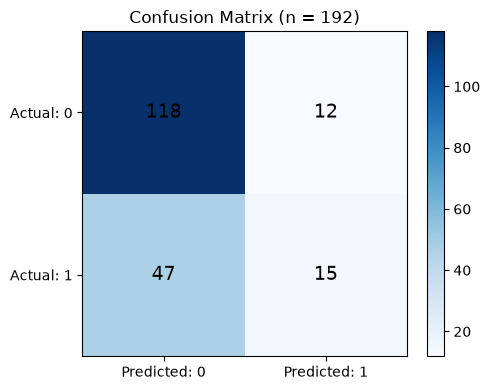

In [7]:
confusion = metrics.confusion_matrix(y_test, y_pred_class)
print('Confusion matrix:')
print(confusion)

TP = confusion[1, 1]
TN = confusion[0, 0]
FP = confusion[0, 1]
FN = confusion[1, 0]

print(f'\nTP = {TP}, TN = {TN}, FP = {FP}, FN = {FN}')

accuracy = (TP + TN) / float(TP + TN + FP + FN)
class_error = (FP + FN) / float(TP + TN + FP + FN)
sensitivity = TP / float(TP + FN)
specificity = TN / float(TN + FP)
fpr = FP / float(FP + TN)
precision = TP / float(TP + FP)

print(f'Classification Accuracy = {accuracy:.6f}')
print(f'Classification Error    = {class_error:.6f}')
print(f'Sensitivity / Recall    = {sensitivity:.6f}')
print(f'Specificity             = {specificity:.6f}')
print(f'False Positive Rate     = {fpr:.6f}')
print(f'Precision               = {precision:.6f}')

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(confusion, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: 0', 'Predicted: 1'])
ax.set_yticklabels(['Actual: 0', 'Actual: 1'])
ax.set_title(f'Confusion Matrix (n = {confusion.sum()})')
for i in range(2):
    for j in range(2):
        ax.text(j, i, confusion[i, j], ha='center', va='center', color='black', fontsize=14)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


### Confusion-matrix results (matches Lab 7 figure)

| | Predicted: 0 | Predicted: 1 |
|--|-------------:|-------------:|
| Actual: 0 | TN = **118** | FP = **12** |
| Actual: 1 | FN = **47** | TP = **15** |

- Classification Accuracy ≈ **0.6927**
- Classification Error ≈ **0.3073**
- Sensitivity / Recall ≈ **0.2419**
- Specificity ≈ **0.9077**
- False Positive Rate ≈ **0.0923**
- Precision ≈ **0.5556**


## Adjusting the Classification Threshold


First 10 predicted probabilities of class 1:
[0.367524 0.283563 0.288959 0.414106 0.15896  0.170652 0.49889  0.513415
 0.276786 0.671894]


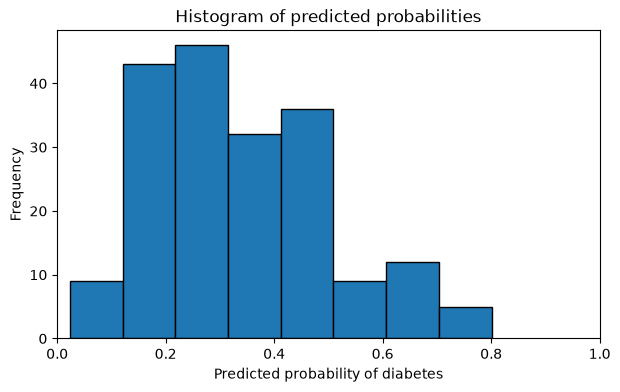

Confusion matrix at threshold 0.3:
[[80 50]
 [16 46]]
Sensitivity at 0.3 = 0.7419 (was 0.2419 at 0.5)
Specificity at 0.3 = 0.6154 (was 0.9077 at 0.5)


In [8]:
y_pred_prob = logreg.predict_proba(X_test)[:, 1]
print('First 10 predicted probabilities of class 1:')
print(y_pred_prob[0:10])

plt.figure(figsize=(7, 4))
plt.hist(y_pred_prob, bins=8, edgecolor='black')
plt.xlim(0, 1)
plt.title('Histogram of predicted probabilities')
plt.xlabel('Predicted probability of diabetes')
plt.ylabel('Frequency')
plt.show()

# Lower threshold to 0.3 to increase sensitivity
y_pred_class_03 = binarize(y_pred_prob.reshape(-1, 1), threshold=0.3).astype(int).ravel()
cm_03 = metrics.confusion_matrix(y_test, y_pred_class_03)
print('Confusion matrix at threshold 0.3:')
print(cm_03)

sens_03 = cm_03[1, 1] / float(cm_03[1, 1] + cm_03[1, 0])
spec_03 = cm_03[0, 0] / float(cm_03[0, 0] + cm_03[0, 1])
print(f'Sensitivity at 0.3 = {sens_03:.4f} (was {sensitivity:.4f} at 0.5)')
print(f'Specificity at 0.3 = {spec_03:.4f} (was {specificity:.4f} at 0.5)')


## ROC Curve and AUC


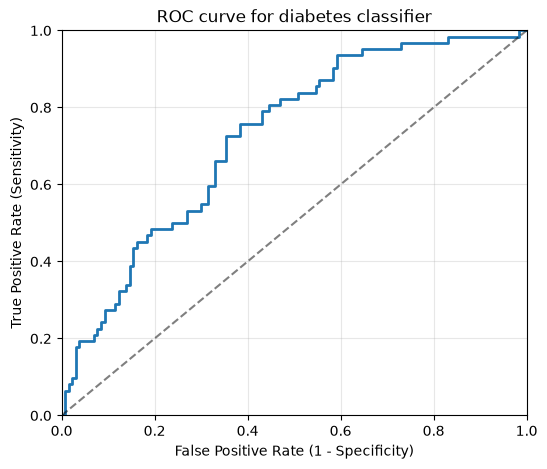

AUC = 0.724566
10-fold CV AUC (mean) = 0.737823


In [9]:
fpr_curve, tpr_curve, thresholds = metrics.roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr_curve, tpr_curve, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for diabetes classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True, alpha=0.3)
plt.show()

auc = metrics.roc_auc_score(y_test, y_pred_prob)
print(f'AUC = {auc:.6f}')

cv_auc = cross_val_score(logreg, X, y, cv=10, scoring='roc_auc').mean()
print(f'10-fold CV AUC (mean) = {cv_auc:.6f}')


## K-Fold Cross-Validation

In **5-fold CV**, data are split into 5 folds. Each fold is used once as the test set while the other 4 train the model. Scores are averaged.


In [10]:
cv_acc = cross_val_score(logreg, X, y, cv=5, scoring='accuracy')
print('5-fold CV accuracy scores:', cv_acc)
print(f'Mean 5-fold CV accuracy = {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})')

cv_recall = cross_val_score(logreg, X, y, cv=5, scoring='recall')
print(f'Mean 5-fold CV recall (sensitivity) = {cv_recall.mean():.4f}')

cv_precision = cross_val_score(logreg, X, y, cv=5, scoring='precision')
print(f'Mean 5-fold CV precision = {cv_precision.mean():.4f}')


5-fold CV accuracy scores: [0.701299 0.668831 0.688312 0.718954 0.666667]
Mean 5-fold CV accuracy = 0.6888 (+/- 0.0198)


Mean 5-fold CV recall (sensitivity) = 0.3321
Mean 5-fold CV precision = 0.6011


## Summary — Lab 7 Answers

### Quiz
| Part | Result |
|------|--------|
| I MAE | **41.7273** |
| I MSE | **1973.1818** |
| I RMSE | **44.4205** |
| II TP, FP, TN, FN | **3, 1, 4, 2** |
| II Accuracy | **0.70** |
| II Classification Error | **0.30** |
| II Precision | **0.75** |
| II Recall / Sensitivity | **0.60** |
| II Specificity | **0.80** |
| II FPR | **0.20** |
| III New predictions (thresh=0.3) | **[1, 0, 1, 1, 1, 1]** |

### Practical diabetes CM (n=192)
Accuracy **0.6927**, Error **0.3073**, Sensitivity **0.2419**, Specificity **0.9077**, FPR **0.0923**, Precision **0.5556**

---
**Amir Ali Eslami — 501200510**
